**step-1: import the packages and read the data**

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

visa_df=pd.read_csv(r"C:\Users\vaish\Documents\NareshIT\GEN_AI\Data_Files\Visadataset.csv")
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


**step-2: Seperate Cat and Num columns**

In [114]:
cat=visa_df.select_dtypes(include='str').columns.tolist()
num=visa_df.select_dtypes(include='str').columns.tolist()

- Frequency table
- Relative frequency table
- Bar chart
- Pie chart

**step-3: Frequency table**

In [81]:
visa_df['continent']

0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: str

In [82]:
visa_df['continent'].unique()

<ArrowStringArray>
['Asia', 'Africa', 'North America', 'Europe', 'South America', 'Oceania']
Length: 6, dtype: str

In [83]:
visa_df['continent'].nunique()

6

- There are 25480 applicants fromm 6 continents
- Number of applicants from each continent: **Fequency table**

In [84]:
# Number of applicants from 'Asia'
visa_df  # DF
visa_df['continent'] # one column
con=visa_df['continent']=='Asia'  # one class
np.sum(con)  # 1+1+1+1+0+1+0+1
visa_df[con]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
5,EZYV06,Asia,Master's,Y,N,2339,2012,South,78252.1400,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [85]:
con=visa_df['continent']=='Asia'
np.sum(con)

con=visa_df['continent']=='Africa'
np.sum(con)

con=visa_df['continent']=='NorthAmerica'
np.sum(con)

cont_class=visa_df['continent'].unique()
freq=[]
for i in cont_class:
    con=visa_df['continent']==i
    freq.append(np.sum(con))
    
pd.DataFrame(zip(cont_class,freq),
             columns=['Class','Frequency'])

,Class,Frequency
0,Asia,16861
1,Africa,551
2,North America,3292
3,Europe,3732
4,South America,852
5,Oceania,192


**Value_Counts**

In [87]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [88]:
type(visa_df['continent'].value_counts())

pandas.Series

In [89]:
keys=visa_df['continent'].value_counts().keys()
values=visa_df['continent'].value_counts().values
pd.DataFrame(zip(keys,values),columns=['Class','Frequency'])

,Class,Frequency
0,Asia,16861
1,Europe,3732
2,North America,3292
3,South America,852
4,Africa,551
5,Oceania,192


In [90]:
# what is the query in sql  we do groupby 
list(visa_df.groupby(by='continent'))

[('Africa',
           case_id continent education_of_employee has_job_experience  \
  4         EZYV05    Africa              Master's                  Y   
  18        EZYV19    Africa              Master's                  Y   
  74        EZYV75    Africa              Master's                  Y   
  194      EZYV195    Africa              Master's                  Y   
  242      EZYV243    Africa            Bachelor's                  N   
  ...          ...       ...                   ...                ...   
  25385  EZYV25386    Africa             Doctorate                  Y   
  25408  EZYV25409    Africa              Master's                  Y   
  25443  EZYV25444    Africa            Bachelor's                  N   
  25446  EZYV25447    Africa              Master's                  N   
  25474  EZYV25475    Africa             Doctorate                  N   
  
        requires_job_training  no_of_employees  yr_of_estab  \
  4                         N             1082

In [91]:
visa_df.groupby(by='continent').count()

,case_id,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
continent,,,,,,,,,,,
Africa,551,551,551,551,551,551,551,551,551,551,551
Asia,16861,16861,16861,16861,16861,16861,16861,16861,16861,16861,16861
Europe,3732,3732,3732,3732,3732,3732,3732,3732,3732,3732,3732
North America,3292,3292,3292,3292,3292,3292,3292,3292,3292,3292,3292
Oceania,192,192,192,192,192,192,192,192,192,192,192
South America,852,852,852,852,852,852,852,852,852,852,852


In [92]:
visa_df.groupby(by='continent').count()['case_id']

continent
Africa             551
Asia             16861
Europe            3732
North America     3292
Oceania            192
South America      852
Name: case_id, dtype: int64

In [ ]:
# except case id do for all other columns

**4th Aug 2026**

**Bar chart**

- x-axis Class names(keys)
- y-axis Frequency names(Values)

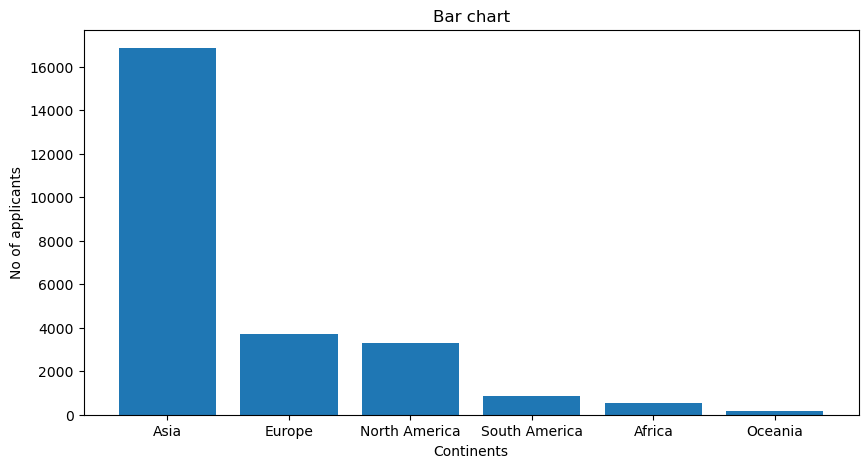

In [93]:
plt.figure(figsize=(10,5))
plt.bar(keys,values)
plt.xlabel('Continents')
plt.ylabel('No of applicants')
plt.title('Bar chart')
plt.show()

In [94]:
from matplotlib.colors import CSS4_COLORS
CSS4_COLORS

{'aliceblue': '#F0F8FF',
 'antiquewhite': '#FAEBD7',
 'aqua': '#00FFFF',
 'aquamarine': '#7FFFD4',
 'azure': '#F0FFFF',
 'beige': '#F5F5DC',
 'bisque': '#FFE4C4',
 'black': '#000000',
 'blanchedalmond': '#FFEBCD',
 'blue': '#0000FF',
 'blueviolet': '#8A2BE2',
 'brown': '#A52A2A',
 'burlywood': '#DEB887',
 'cadetblue': '#5F9EA0',
 'chartreuse': '#7FFF00',
 'chocolate': '#D2691E',
 'coral': '#FF7F50',
 'cornflowerblue': '#6495ED',
 'cornsilk': '#FFF8DC',
 'crimson': '#DC143C',
 'cyan': '#00FFFF',
 'darkblue': '#00008B',
 'darkcyan': '#008B8B',
 'darkgoldenrod': '#B8860B',
 'darkgray': '#A9A9A9',
 'darkgreen': '#006400',
 'darkgrey': '#A9A9A9',
 'darkkhaki': '#BDB76B',
 'darkmagenta': '#8B008B',
 'darkolivegreen': '#556B2F',
 'darkorange': '#FF8C00',
 'darkorchid': '#9932CC',
 'darkred': '#8B0000',
 'darksalmon': '#E9967A',
 'darkseagreen': '#8FBC8F',
 'darkslateblue': '#483D8B',
 'darkslategray': '#2F4F4F',
 'darkslategrey': '#2F4F4F',
 'darkturquoise': '#00CED1',
 'darkviolet': '#9400D3

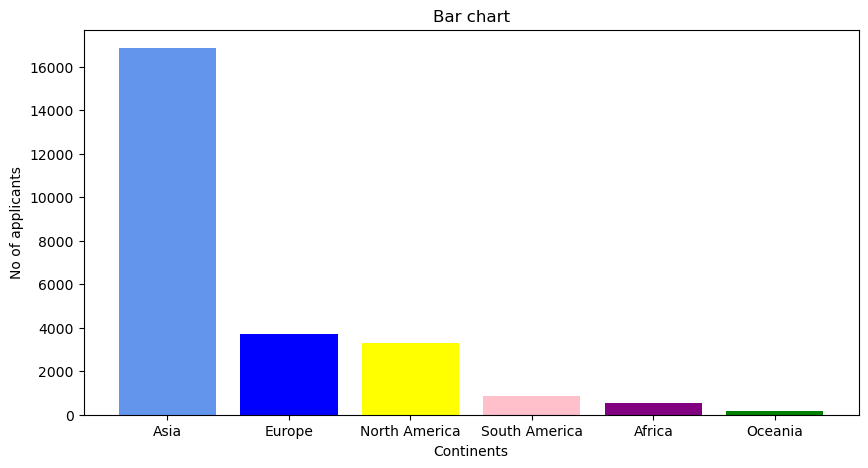

In [40]:
colors=['cornflowerblue','Blue','Yellow','Pink','Purple','Green']
plt.figure(figsize=(10,5))
plt.bar(keys,values,color=colors)
plt.xlabel('Continents')
plt.ylabel('No of applicants')
plt.title('Bar chart')
plt.savefig('Continent_bar.jpg')

plt.show()

**Pie chart**

- autopct = %a.bf%%
  
- first % is the formatting

- a : how much min width

- b : after point how many decimals

- %% : % symbol

- %1.1f%% : 40.2%

- %2.2f%% : 423.23

- startangle is rotational angle

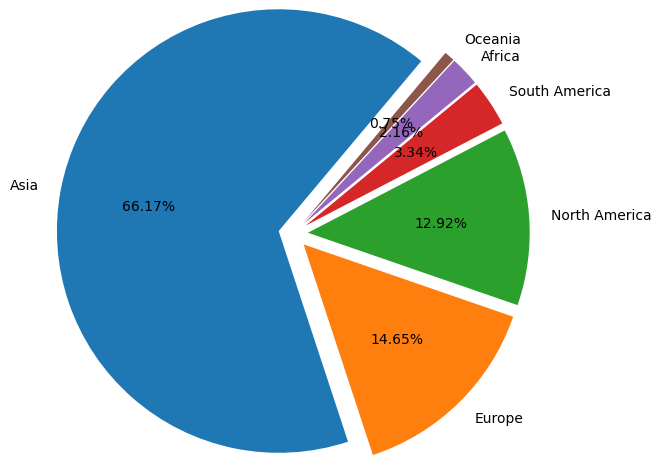

In [59]:
keys=visa_df['continent'].value_counts().keys()
values=visa_df['continent'].value_counts().values
#plt.pie(x,labels)
plt.pie(values,
        explode=[0.1 for i in range(6)],
        labels=keys,
        autopct='%1.2f%%',
        radius=1.5,
        startangle=50)
plt.savefig('Continent_pie.jpg')
plt.show()

**Relative Frequency table**

In [95]:
visa_df['continent'].value_counts(normalize=True)

continent
Asia             0.661735
Europe           0.146468
North America    0.129199
South America    0.033438
Africa           0.021625
Oceania          0.007535
Name: proportion, dtype: float64

**Subplots**

<Axes: >

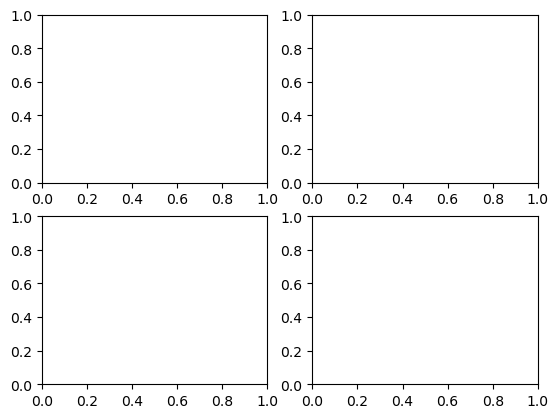

In [96]:
plt.subplot(2,2,1)
plt.subplot(2,2,2)
plt.subplot(2,2,3)
plt.subplot(2,2,4)

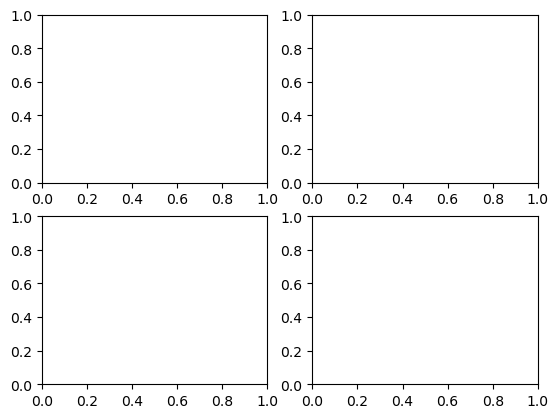

In [97]:
# plt.subplot(2,2,1)
# plt.subplot(2,2,2)
# plt.subplot(2,2,3)

for i in range(1,5):
    plt.subplot(2,2,i)

In [115]:
cat

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

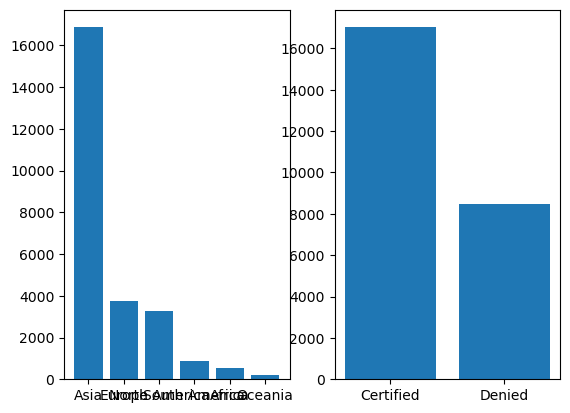

In [105]:
cols=['continent','case_status']

keys1=visa_df['continent'].value_counts().keys()
values1=visa_df['continent'].value_counts().values
plt.subplot(1,2,1)
plt.bar(keys1,values1)

keys2=visa_df['case_status'].value_counts().keys()
values2=visa_df['case_status'].value_counts().values
plt.subplot(1,2,2)
plt.bar(keys2,values2)
plt.show()

<BarContainer object of 2 artists>

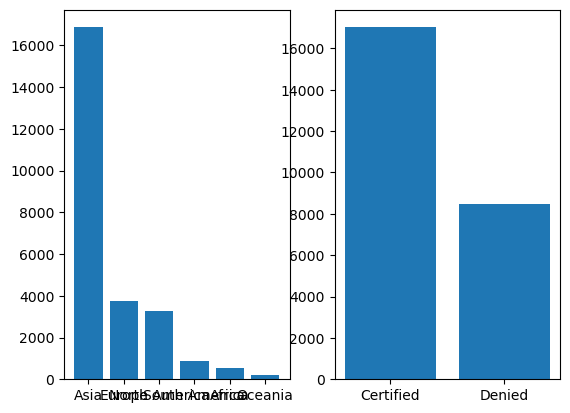

In [109]:
cols=['continent','case_status']

keys1=visa_df['continent'].value_counts().keys()
values1=visa_df['continent'].value_counts().values
keys2=visa_df['case_status'].value_counts().keys()
values2=visa_df['case_status'].value_counts().values

plt.subplot(1,2,1).bar(keys1,values1)
plt.subplot(1,2,2).bar(keys2,values2)

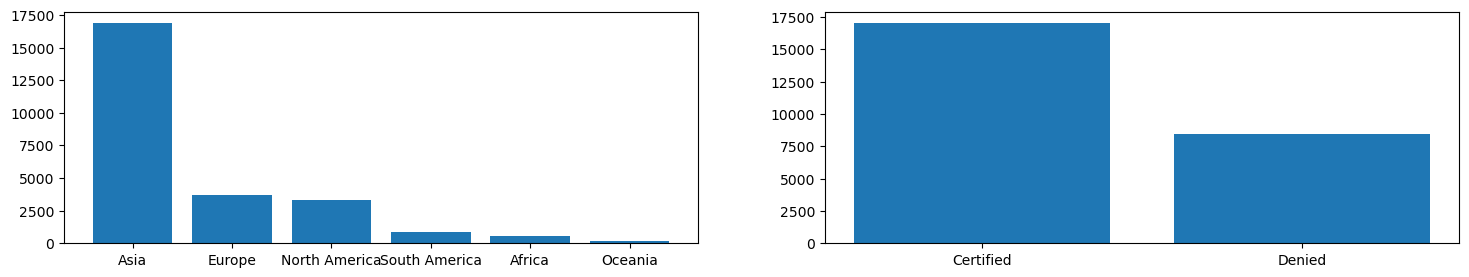

In [112]:
cols=['continent','case_status']
plt.figure(figsize=(18,3))
for i in range(len(cols)):
    c=cols[i]
    keys=visa_df[c].value_counts().keys()
    values=visa_df[c].value_counts().values
    plt.subplot(1,2,i+1).bar(keys,values)